# Calamity AI: Domain Matrix EDA

This notebook visualizes the two fundamental domain matrices of Calamity AI:
1. **Tectonic Matrix:** (Earthquakes + Volcanism)
2. **Atmospheric Impact Matrix:** (Wildfires/Floods/Storms + Casualties/Damage)

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# Load Matrices
df_tectonic = pd.read_csv('../data/processed/tectonic_matrix.csv')
df_impact = pd.read_csv('../data/processed/atmospheric_impact_matrix.csv')

## 1. Gutenberg-Richter Frequency-Magnitude Law (Tectonic Matrix)
The physical law of seismology states that earthquake frequencies drop exponentially as magnitude increases.

In [3]:
df_eq = df_tectonic[df_tectonic['event_type'] == 'earthquake'].copy()
df_eq['mag_bin'] = df_eq['severity'].round(1)
freq = df_eq.groupby('mag_bin').size().reset_index(name='count')
freq['log10_count'] = np.log10(freq['count'])

fig = px.scatter(
    freq, 
    x='mag_bin', 
    y='log10_count', 
    title="Gutenberg-Richter Frequency-Magnitude Distribution (Log-Linear)",
    labels={'mag_bin': 'Magnitude', 'log10_count': 'Log10(Frequency)'},
    trendline="ols"
)
fig.show()

## 2. Atmospheric Impact Correlation Heatmap
How does the frequency of NASA EONET anomalies correlate to physical EM-DAT human impact?

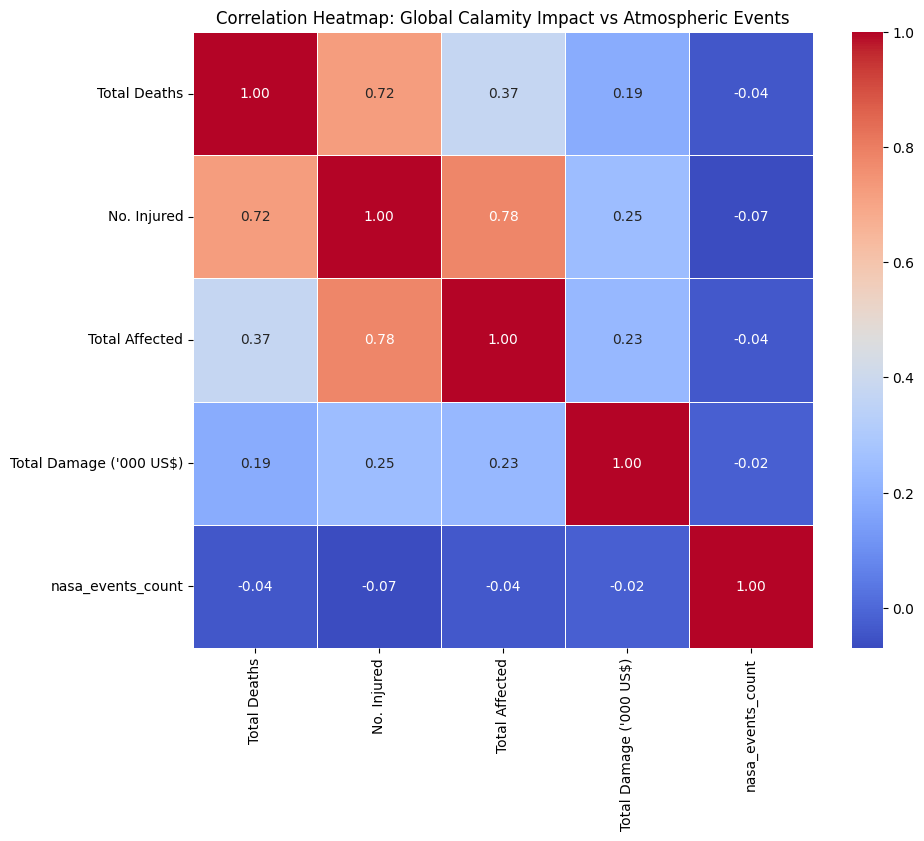

In [4]:
# Filter numerical targets for correlation
corr_cols = [
    'Total Deaths', 'No. Injured', 'Total Affected', 
    "Total Damage ('000 US$)", 'nasa_events_count'
]
df_corr = df_impact[corr_cols].dropna()

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Global Calamity Impact vs Atmospheric Events")
plt.show()

## 3. Geospatial Density of the Tectonic Engine
Mapping the "Ring of Fire" utilizing the clustered `grid_lat` and `grid_lon` parameters.

In [5]:
density_map = df_tectonic.groupby(['grid_lat', 'grid_lon', 'event_type']).size().reset_index(name='event_count')

fig = px.scatter_geo(
    density_map,
    lat='grid_lat',
    lon='grid_lon',
    size='event_count',
    color='event_type',
    title="Global Tectonic Density (Earthquakes vs Volcanism)",
    projection="natural earth",
    opacity=0.7
)
fig.show()